# Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt
import scipy.integrate as integrate
from statsmodels.tsa.ar_model import AutoReg

# Helper Function

In [ ]:
def ButterBandpassFilter(InputSignal, LowCutoff, HighCutoff, SamplingRate, Order):
    Nyq = 0.5 * SamplingRate
    Low = LowCutoff / Nyq
    High = HighCutoff / Nyq
    Numerator, Denominator = butter(Order, [Low, High], btype='band')
    Filtered = filtfilt(Numerator, Denominator, InputSignal)
    return Filtered


#Read data

In [ ]:
DataFrame = pd.read_excel('2- Horizontal Signals.xlsx', header=None)
PatientNames = DataFrame.iloc[-1, :].values
RawSignalsMatrix = DataFrame.iloc[:-1, :].T.values.astype(float)

# Golab variable

In [ ]:
SamplingRate = 176
LowCut = 0.5
HighCut = 20
FilterOrder = 3

SignalsNoDC = []
FilteredSignals = []

# Pre - processing

# 1- Remove DC component
# 2- Filter signal

In [ ]:
for I in range(len(RawSignalsMatrix)):
    NoDCSignal = RawSignalsMatrix[I] - np.mean(RawSignalsMatrix[I])
    SignalsNoDC.append(NoDCSignal)
    FinalFiltered = ButterBandpassFilter(NoDCSignal, LowCut, HighCut, SamplingRate, FilterOrder)
    FilteredSignals.append(FinalFiltered)

SignalsNoDC = np.array(SignalsNoDC)
FilteredSignals = np.array(FilteredSignals)

NumSamples = RawSignalsMatrix.shape[1]
TimeAxis = np.arange(0, NumSamples)


# Plot Original signal and No DC-Component signal and Filtered signal

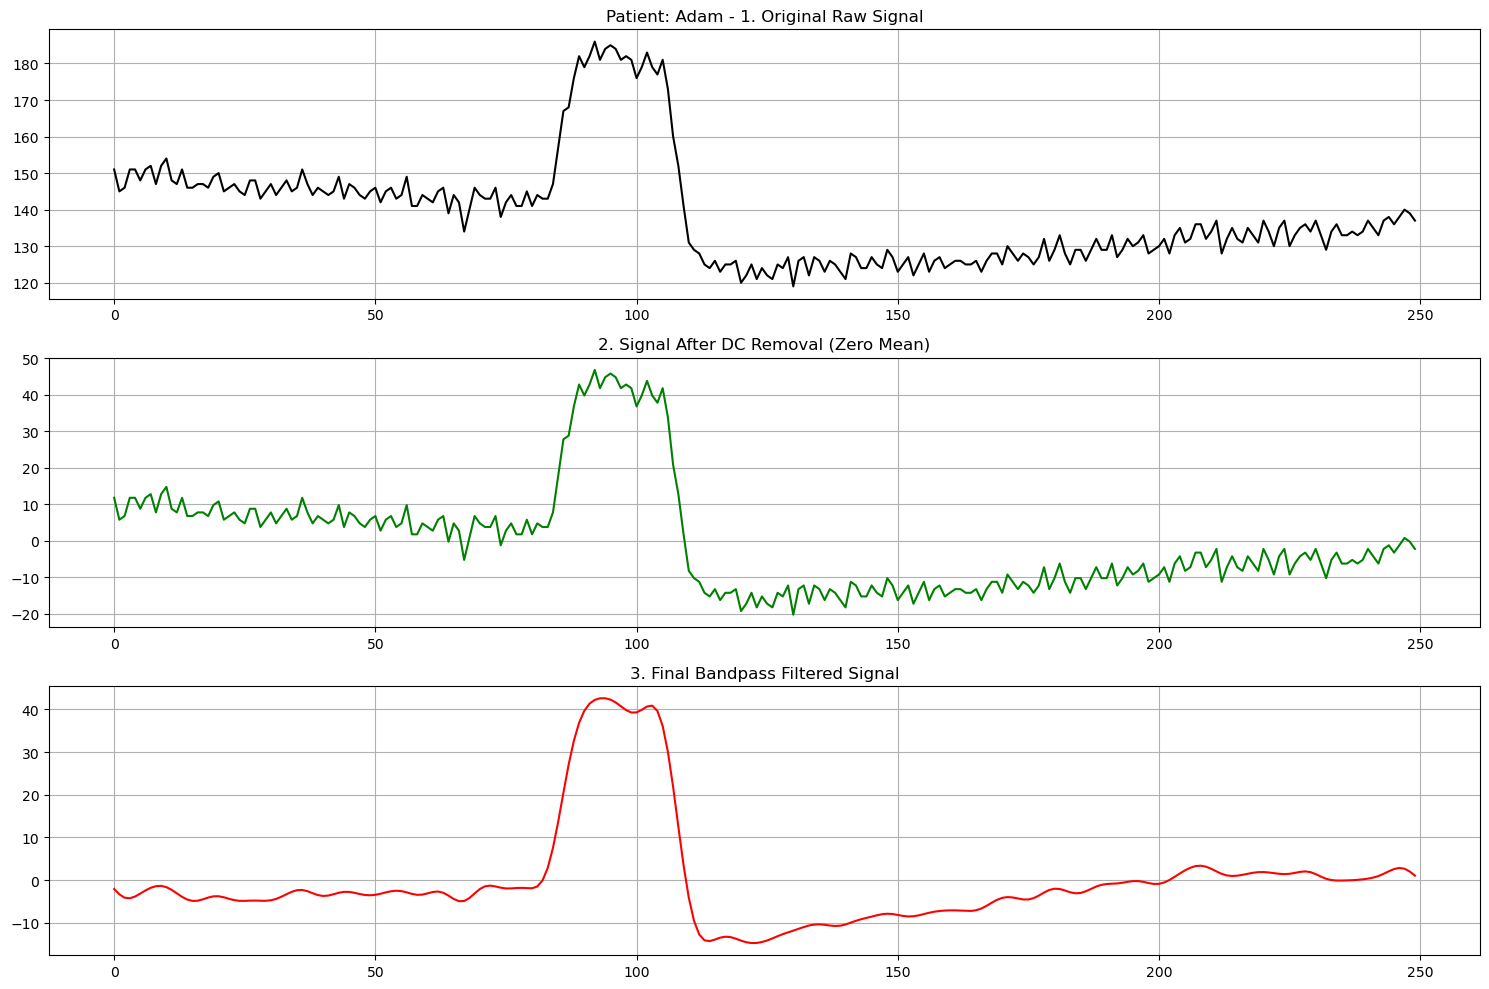

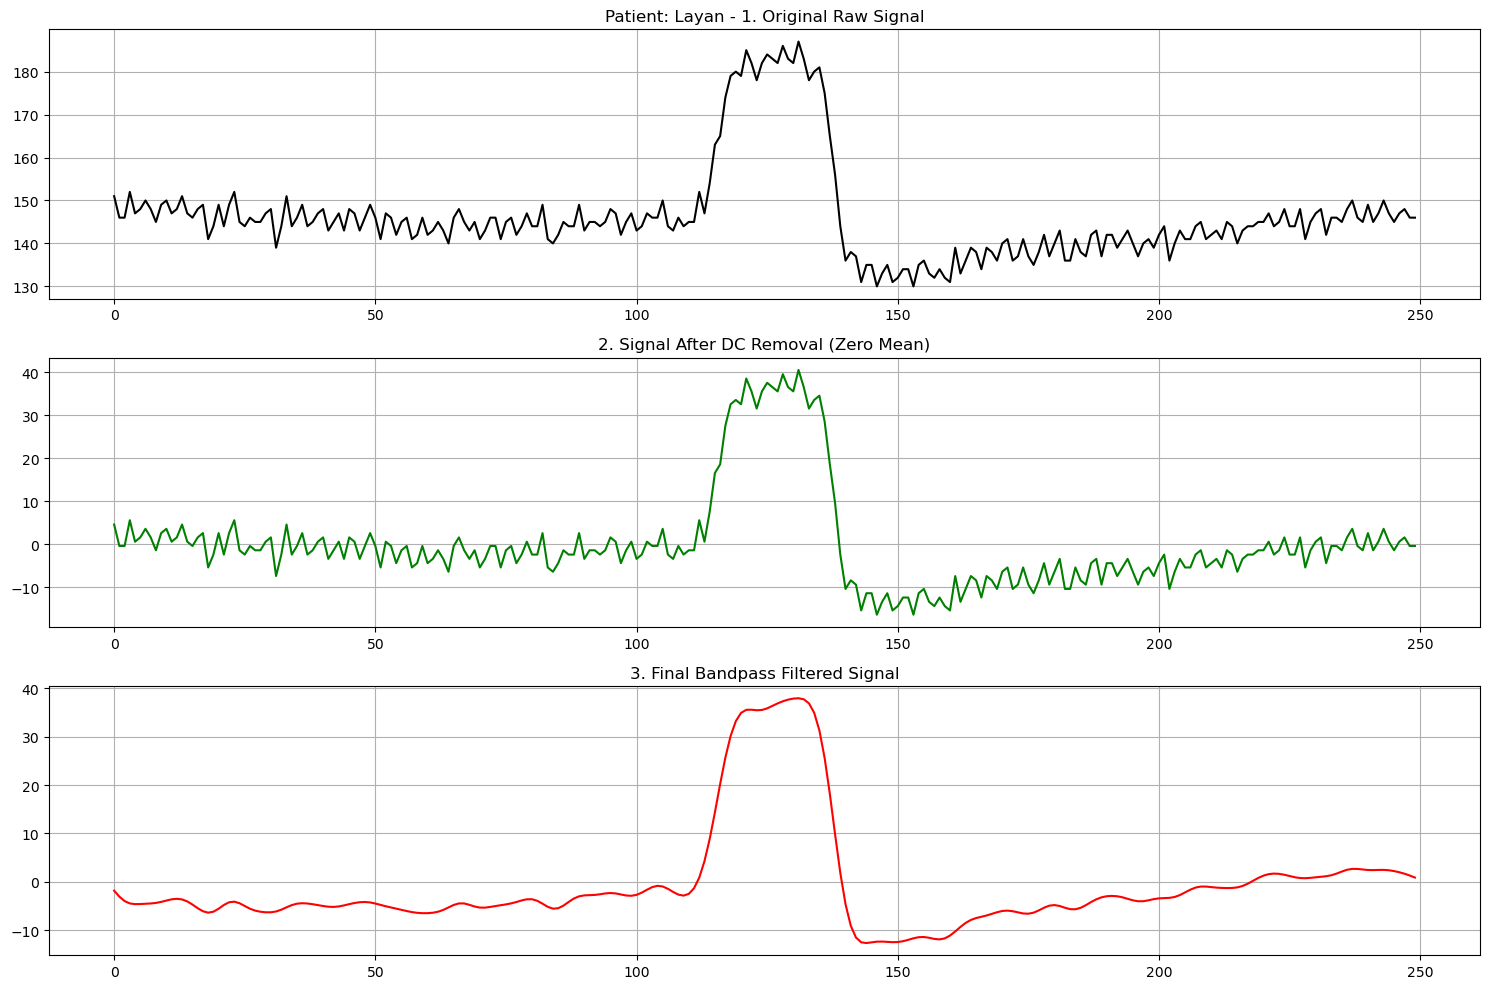

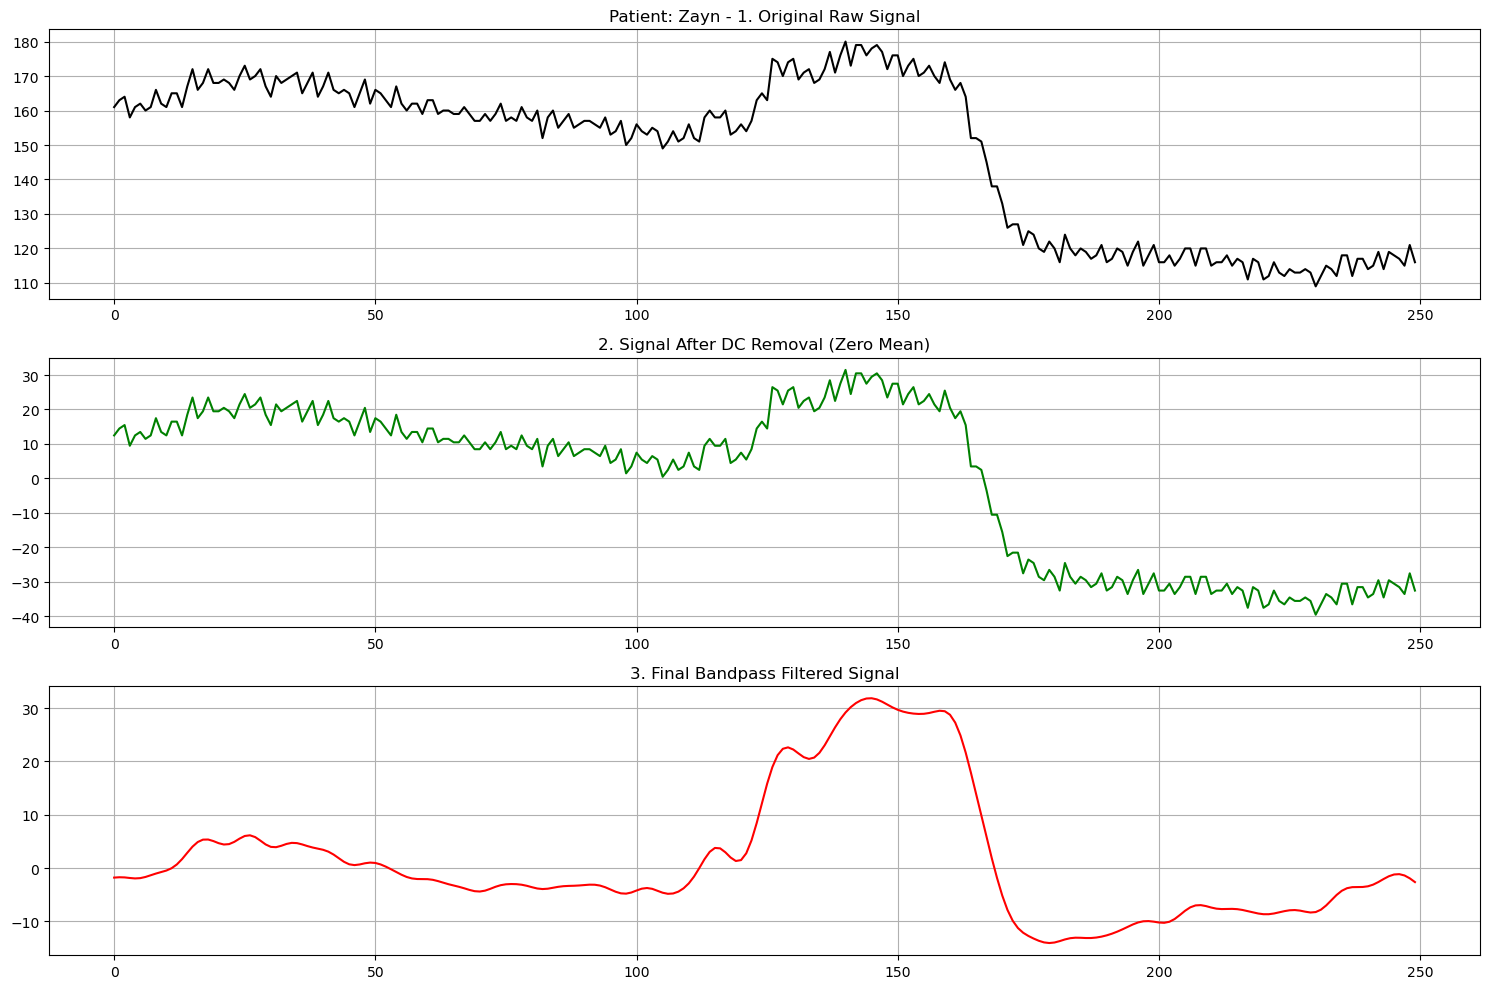

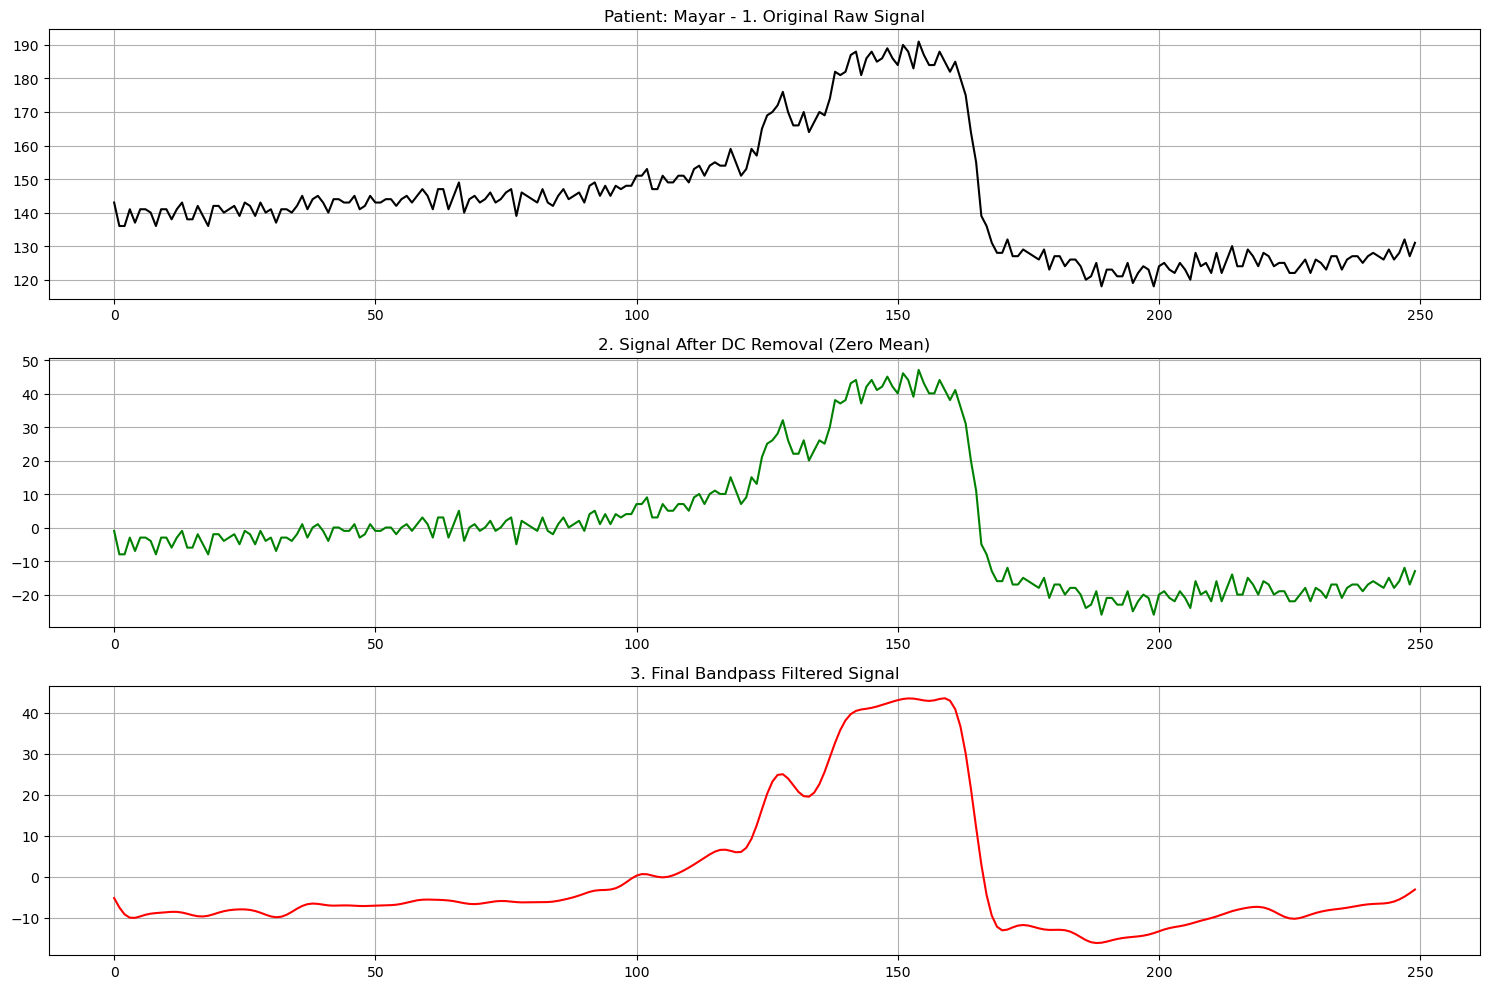

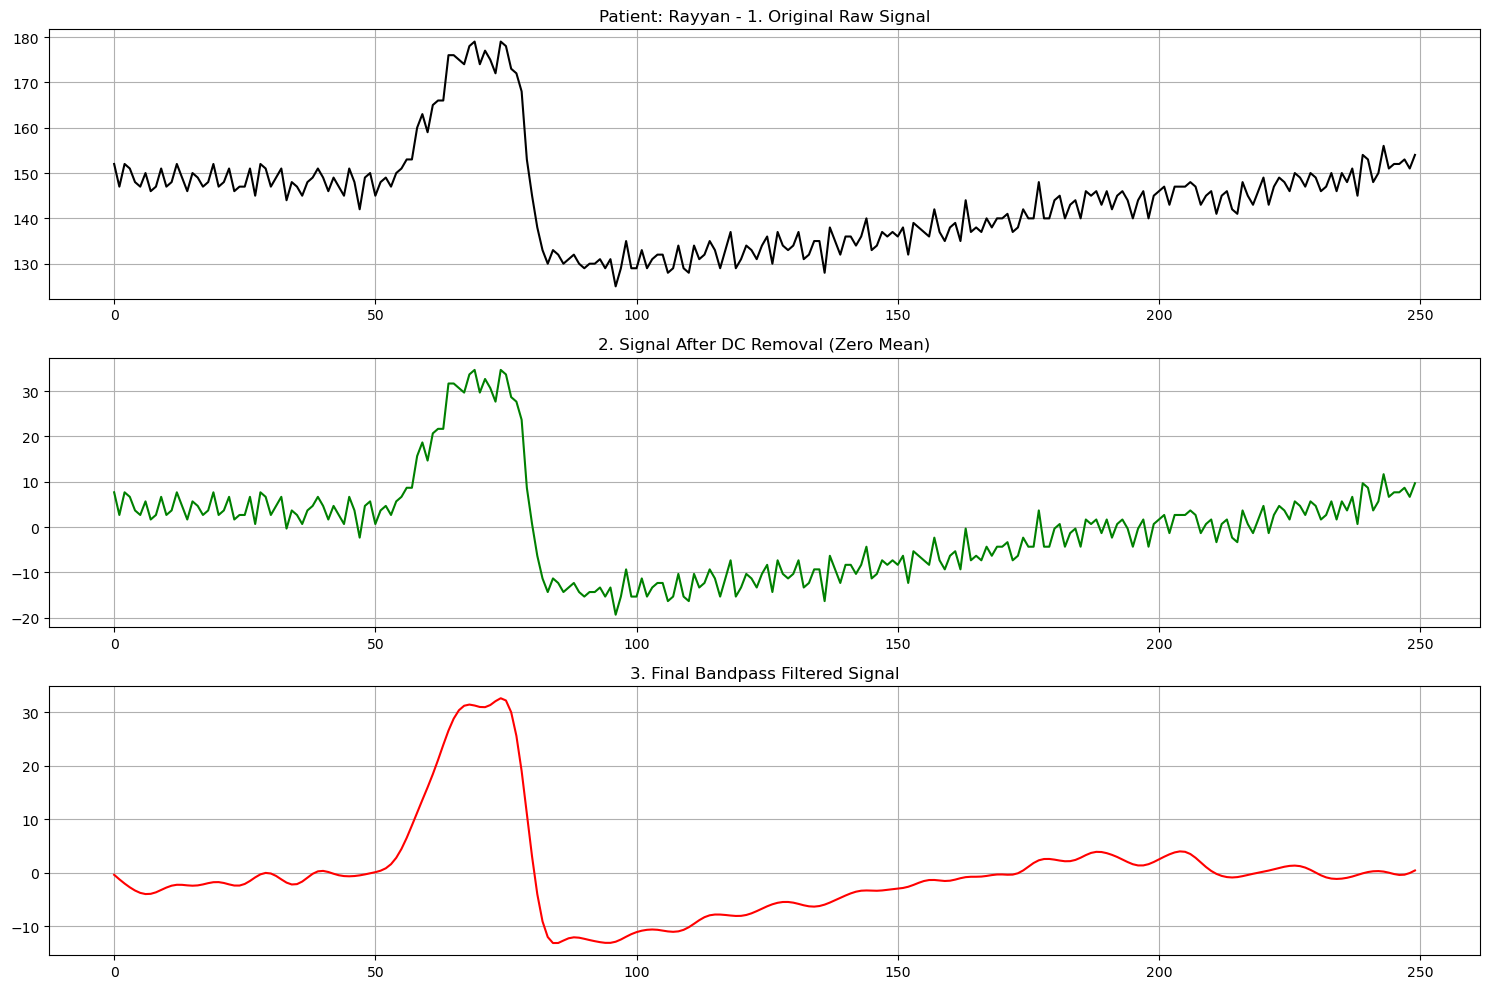

In [ ]:
for I in range(5):
    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(TimeAxis, RawSignalsMatrix[I], color='black')
    plt.title(f'Patient: {PatientNames[I]} - 1. Original Raw Signal')
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(TimeAxis, SignalsNoDC[I], color='green')
    plt.title('2. Signal After DC Removal (Zero Mean)')
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(TimeAxis, FilteredSignals[I], color='red')
    plt.title('3. Final Bandpass Filtered Signal')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Feature Extraction

In [ ]:
FinalFeaturesList = []

for I in range(len(FilteredSignals)):
    CurrentSignal = FilteredSignals[I]

    MeanValue = np.mean(CurrentSignal)
    StandardDeviation = np.std(CurrentSignal)
    MaxPeakValue = np.max(CurrentSignal)
    AreaUnderCurve = integrate.trapezoid(np.abs(CurrentSignal))

    ArModel = AutoReg(CurrentSignal, lags=2)
    ArFit = ArModel.fit()
    ArCoeffs = ArFit.params[0:]

    FinalFeaturesList.append([
        PatientNames[I],
        MeanValue,
        StandardDeviation,
        MaxPeakValue,
        AreaUnderCurve,
        ArCoeffs[0],
        ArCoeffs[1],
        ArCoeffs[2]
    ])


# Final features extracted

In [ ]:
FinalFeaturesTable = pd.DataFrame(FinalFeaturesList, columns=[
    'Patient Name',
    'Mean',
    'Standard Deviation',
    'MaxPeak',
    'Area Under Curve',
    'ArCoeff1',
    'ArCoeff2',
    'ArCoeff3'
])

print(FinalFeaturesTable)
FinalFeaturesTable.to_excel('Extracted Signal Features.xlsx', index=False)
print('File saved successfully as: Extracted Signal Features.xlsx')

   Patient Name      Mean  Standard Deviation    MaxPeak  Area Under Curve  \
0          Adam -0.019685           12.576411  42.617669       1859.444430   
1         Layan -0.589406           11.298189  37.961193       1793.115397   
2          Zayn  1.520267           12.109419  31.849591       2163.753240   
3         Mayar -0.225052           16.386891  43.549702       3055.810056   
4        Rayyan -0.015564            9.301229  32.615876       1389.047580   
5          Juri -0.095810           12.656402  12.160421       1803.424103   
6         Faris  0.475423           11.975488  14.096841       1702.238809   
7          Tala  1.067004           11.262566  12.562050       1688.268899   
8          Kian -1.041286           10.350904   8.788068       1283.258535   
9          Ayla -0.158167           10.042504   9.351067       1234.102513   
10        Hamza  0.839952            3.044275   6.390194        641.447008   
11        Randa  0.871594            3.152509   6.077858        

# Read Test signal

In [ ]:
TestSignalRaw = np.loadtxt('3- Test Signal.txt').astype(float)

TestNoDC = TestSignalRaw - np.mean(TestSignalRaw)

TestFiltered = ButterBandpassFilter(TestNoDC, LowCut, HighCut, SamplingRate, FilterOrder)


# Pre - Processing on test signal

In [ ]:
TestMean = np.mean(TestFiltered)
TestStd = np.std(TestFiltered)
TestMax = np.max(TestFiltered)
TestArea = integrate.trapezoid(np.abs(TestFiltered))

TestArModel = AutoReg(TestFiltered, lags=2).fit()
TestArCoeffs = TestArModel.params[0:]

TestFeatureVector = np.array([
    TestMean, TestStd, TestMax, TestArea,
    TestArCoeffs[0], TestArCoeffs[1], TestArCoeffs[2]
])


# Predict Test Signal belongs to any patient

In [ ]:
Distances = []

TrainingMatrix = FinalFeaturesTable.iloc[:, 1:].values

for I in range(len(TrainingMatrix)):
    CurrentPatientVector = TrainingMatrix[I]
    Distance = np.linalg.norm(TestFeatureVector - CurrentPatientVector)
    Distances.append(Distance)

MinDistanceIndex = np.argmin(Distances)
PredictedPatient = PatientNames[MinDistanceIndex]

print(f'Prediction: This signal belongs to {PredictedPatient}')
print(f'Minimum Euclidean Distance: {Distances[MinDistanceIndex]}')


Prediction: This signal belongs to Juri
Minimum Euclidean Distance: 0.0


# Check test signal already in data

In [ ]:
JuriIndex = np.where(PatientNames == 'Juri')[0][0]
JuriRawData = RawSignalsMatrix[JuriIndex]

IsMatch = np.array_equal(JuriRawData, TestSignalRaw)

print(f"Is Test Signal exactly the same as Juri's raw data? {IsMatch}")

if IsMatch:
    print('Match found! The test signal is identical to Juri\'s data.')
else:
    print('No match. There is at least one difference between the signals.')


Is Test Signal exactly the same as Juri's raw data? True
Match found! The test signal is identical to Juri's data.
